In [1]:
import os, glob, inspect, textwrap
import torch
import nugraph as ng

torch.set_float32_matmul_precision("medium")

DATA_PATH = "/home/apaudel/NuGraph/scripts/merged1_Aug6_40k_pmtpmt_g4lepdir_with_vpred_nexusonly"
RUN_NAME = "merged1_Aug20_40k_g4lepdir_tpc_only_semantic_vertex_direction_fixedvpred_nexusfeat_ep100_bs32_in8_sp5"

ckpts = glob.glob(f"/home/apaudel/NuGraph/logs/{RUN_NAME}/**/*.ckpt", recursive=True)
assert ckpts, f"No checkpoint found for {RUN_NAME}"

CKPT = max(ckpts, key=os.path.getmtime)

print("Using checkpoint:")
print(CKPT)

Data = ng.data.H5DataModule
Model = ng.models.NuGraph3

nudata = Data(
    DATA_PATH,
    batch_size=32,
    num_workers=0,
    model=Model,
    shuffle="random",
    featext3d=True,   # same as --3dfeatext
)

model = Model.load_from_checkpoint(CKPT)
model.eval()

print("\nData:")
print("event_classes:", nudata.event_classes)
print("semantic_classes:", nudata.semantic_classes)
print("train/val/test:", len(nudata.train_dataset), len(nudata.val_dataset), len(nudata.test_dataset))

print("\nModel heads:")
print("has vertex_decoder    =", hasattr(model, "vertex_decoder"))
print("has direction_decoder =", hasattr(model, "direction_decoder"))
print("encoder.sp_net is None =", model.encoder.sp_net is None)

print("\nCheckpoint hparams:")
raw = torch.load(CKPT, map_location="cpu")
hp = raw.get("hyper_parameters", {})
for k in [
    "in_features", "sp_features",
    "semantic_head", "vertex_head", "direction_head",
    "event_head", "use_optical", "use_pmt_pmt",
]:
    print(f"{k:16s} =", hp.get(k, "MISSING"))

print("\nActive direction.py / vertex.py loss code snippets:")

def print_loss_related_source(obj, title):
    src = inspect.getsource(obj.__class__)
    lines = src.splitlines()
    keep = []
    keywords = [
        "loss", "criterion", "cos", "angle", "normalize",
        "logcosh", "smooth", "mse", "l1", "y_vtx", "v_pred", "y_dir", "evt.d", "evt.v"
    ]
    for i, line in enumerate(lines, start=1):
        if any(k.lower() in line.lower() for k in keywords):
            lo = max(1, i - 2)
            hi = min(len(lines), i + 3)
            keep.append((lo, hi))

    # merge ranges
    merged = []
    for lo, hi in keep:
        if not merged or lo > merged[-1][1] + 1:
            merged.append([lo, hi])
        else:
            merged[-1][1] = max(merged[-1][1], hi)

    print("\n" + "="*90)
    print(title)
    print("="*90)

    for lo, hi in merged:
        for j in range(lo, hi + 1):
            print(f"{j:4d}: {lines[j-1]}")
        print("   ...")

print_loss_related_source(model.vertex_decoder, "VertexDecoder")
print_loss_related_source(model.direction_decoder, "DirectionDecoder")

# quick batch sanity
batch = next(iter(nudata.test_dataloader()))
print("\nBatch sanity before forward:")
print("has evt.y_vtx  =", hasattr(batch["evt"], "y_vtx"))
print("has evt.v_pred =", hasattr(batch["evt"], "v_pred"))
print("has evt.y_dir  =", hasattr(batch["evt"], "y_dir"))
print("evt.y_vtx shape :", tuple(batch["evt"].y_vtx.shape))
print("evt.v_pred shape:", tuple(batch["evt"].v_pred.shape))
print("evt.y_dir shape :", tuple(batch["evt"].y_dir.shape))
print("sp.x shape      :", tuple(batch["sp"].x.shape))

Using checkpoint:
/home/apaudel/NuGraph/logs/merged1_Aug20_40k_g4lepdir_tpc_only_semantic_vertex_direction_fixedvpred_nexusfeat_ep100_bs32_in8_sp5/version_1/checkpoints/epoch=99-step=94000.ckpt

Data:
event_classes: ['cc_nue', 'es_nue']
semantic_classes: ['pion', 'muon', 'kaon', 'hadron', 'shower', 'lowE_electron', 'michel', 'diffuse']
train/val/test: 30080 1672 1672

Model heads:
has vertex_decoder    = True
has direction_decoder = True
encoder.sp_net is None = False

Checkpoint hparams:
in_features      = 8
sp_features      = 5
semantic_head    = True
vertex_head      = True
direction_head   = True
event_head       = False
use_optical      = False
use_pmt_pmt      = False

Active direction.py / vertex.py loss code snippets:

VertexDecoder
   3:     NuGraph3 vertex decoder module.
   4: 
   5:     The network predicts normalized vertex coordinates.
   6: 
   7:     Normalization:
   8:         x_norm = (x_cm - mean_x) / std_x
   ...
  10:         z_norm = (z_cm - mean_z) / std_z
  11:

Direction output field used: d
Vertex output field used: v
N test events: 1672


,quantity,median,mean,p68,p90
0,fixed v_pred vs true vertex distance,5.480000,8.382000,8.121000,17.760000
1,model predicted vertex vs true vertex distance,6.709000,9.244000,9.200000,17.665001
2,model predicted vertex vs fixed v_pred distance,5.183000,6.649000,7.064000,12.586000
3,direction angle error deg,78.442001,79.650002,106.000999,144.651001
4,axis-only angle error deg,50.669998,49.233002,64.929001,82.688004


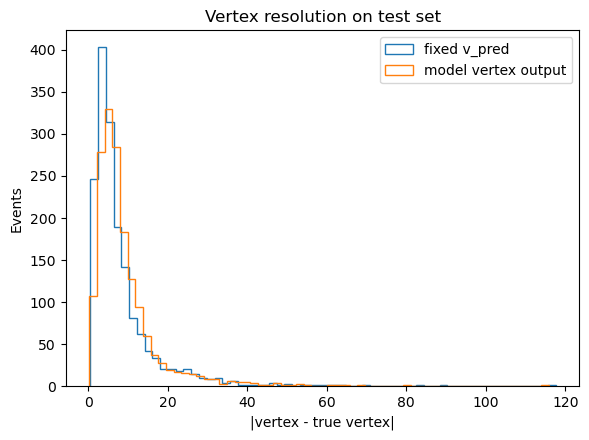

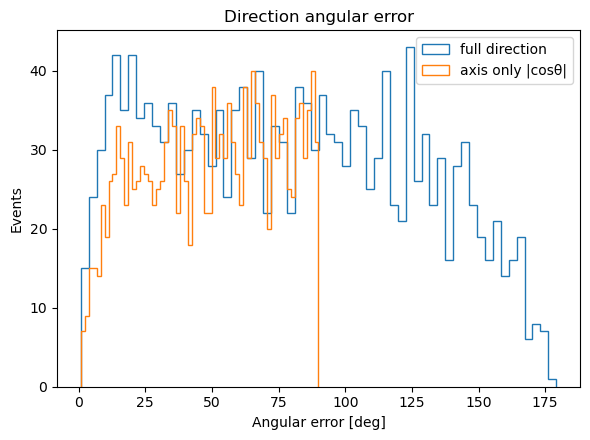

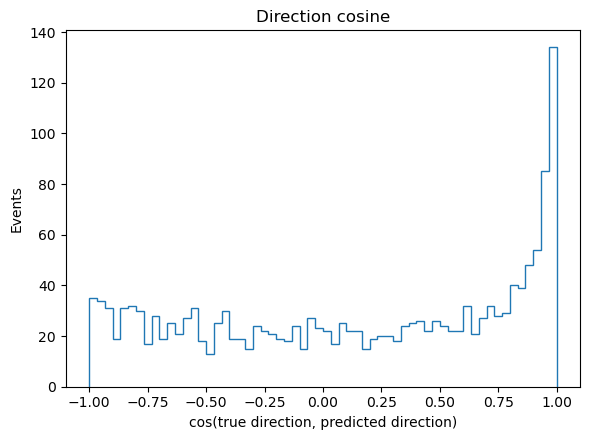

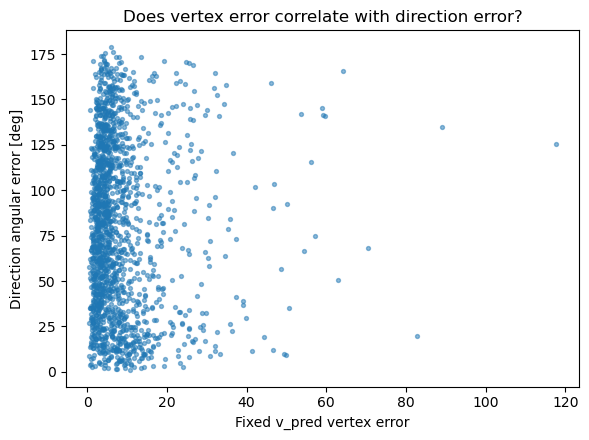

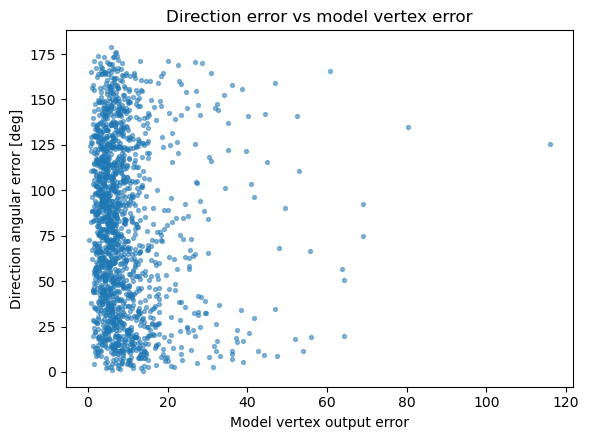

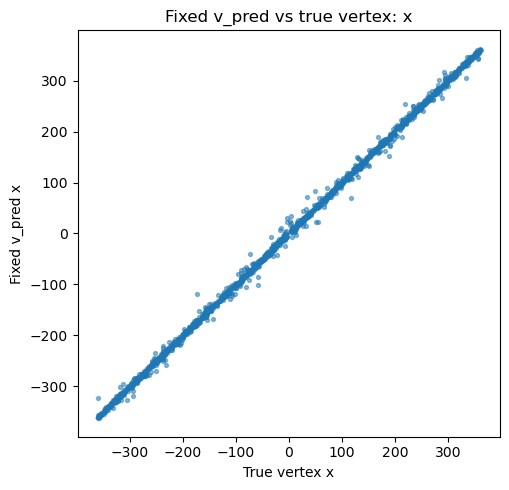

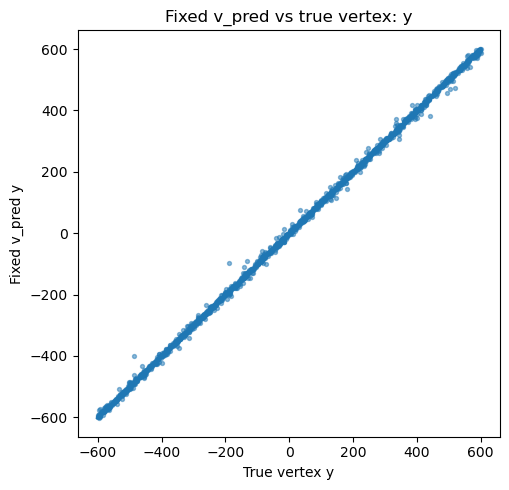

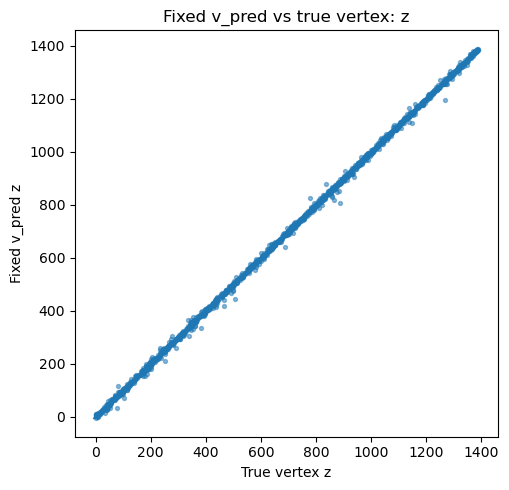

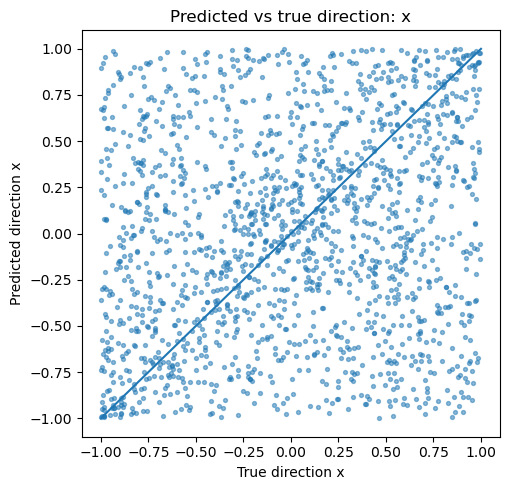

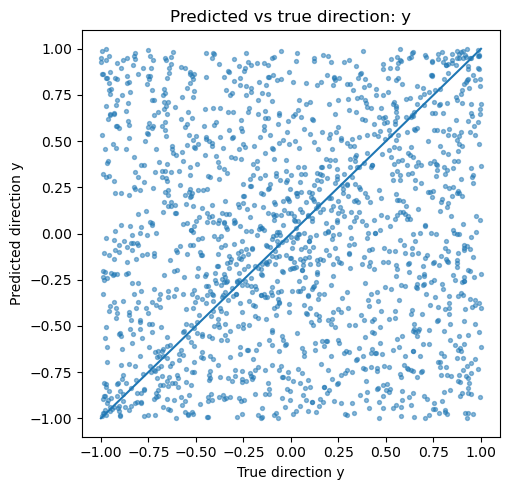

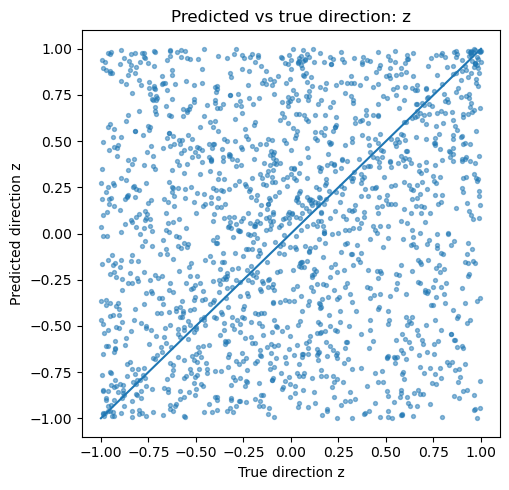

ValueError: Too many bins for data range. Cannot create 60 finite-sized bins.

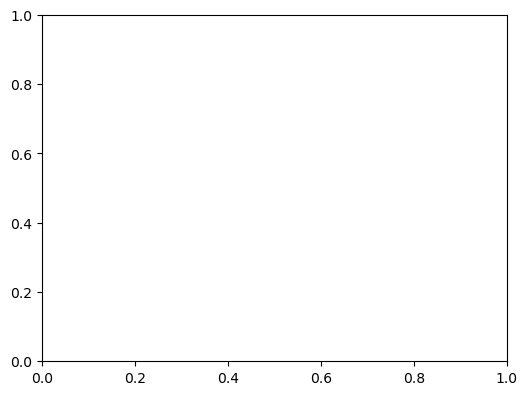

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

def get_evt_field(evt, candidates):
    for name in candidates:
        if hasattr(evt, name):
            return getattr(evt, name), name
    raise RuntimeError(f"None of these fields found: {candidates}")

rows = []

with torch.no_grad():
    for batch in nudata.test_dataloader():
        batch = batch.to(device)

        # Runs semantic + vertex + direction decoders.
        model(batch)

        evt = batch["evt"]

        y_vtx = evt.y_vtx.detach().cpu().numpy()
        v_pred_fixed = evt.v_pred.detach().cpu().numpy()

        # model vertex decoder output
        v_model, v_model_name = get_evt_field(evt, ["v", "vertex", "vtx"])
        v_model = v_model.detach().cpu().numpy()

        y_dir = evt.y_dir.detach().cpu().numpy()

        # direction decoder output
        d_pred, d_pred_name = get_evt_field(evt, ["d", "dir", "direction"])
        d_pred = d_pred.detach().cpu().numpy()

        # Flatten possible shapes
        y_vtx = y_vtx.reshape(-1, 3)
        v_pred_fixed = v_pred_fixed.reshape(-1, 3)
        v_model = v_model.reshape(-1, 3)
        y_dir = y_dir.reshape(-1, 3)
        d_pred = d_pred.reshape(-1, 3)

        for i in range(y_vtx.shape[0]):
            rows.append({
                "true_vx": y_vtx[i, 0],
                "true_vy": y_vtx[i, 1],
                "true_vz": y_vtx[i, 2],

                "fixed_vpred_x": v_pred_fixed[i, 0],
                "fixed_vpred_y": v_pred_fixed[i, 1],
                "fixed_vpred_z": v_pred_fixed[i, 2],

                "model_vx": v_model[i, 0],
                "model_vy": v_model[i, 1],
                "model_vz": v_model[i, 2],

                "true_dx": y_dir[i, 0],
                "true_dy": y_dir[i, 1],
                "true_dz": y_dir[i, 2],

                "pred_dx": d_pred[i, 0],
                "pred_dy": d_pred[i, 1],
                "pred_dz": d_pred[i, 2],
            })

df = pd.DataFrame(rows)

print("Direction output field used:", d_pred_name)
print("Vertex output field used:", v_model_name)
print("N test events:", len(df))

# ---------- metrics ----------
true_v = df[["true_vx", "true_vy", "true_vz"]].values
fixed_v = df[["fixed_vpred_x", "fixed_vpred_y", "fixed_vpred_z"]].values
model_v = df[["model_vx", "model_vy", "model_vz"]].values

true_d = df[["true_dx", "true_dy", "true_dz"]].values
pred_d = df[["pred_dx", "pred_dy", "pred_dz"]].values

def unit(x):
    n = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.clip(n, 1e-12, None)

true_d_u = unit(true_d)
pred_d_u = unit(pred_d)

cosang = np.sum(true_d_u * pred_d_u, axis=1)
cosang = np.clip(cosang, -1, 1)
angle_deg = np.degrees(np.arccos(cosang))

axis_cos = np.abs(cosang)
axis_angle_deg = np.degrees(np.arccos(axis_cos))

fixed_v_err = np.linalg.norm(fixed_v - true_v, axis=1)
model_v_err = np.linalg.norm(model_v - true_v, axis=1)
model_vs_fixed_v_err = np.linalg.norm(model_v - fixed_v, axis=1)

pred_norm = np.linalg.norm(pred_d, axis=1)
true_norm = np.linalg.norm(true_d, axis=1)

summary = pd.DataFrame([
    {
        "quantity": "fixed v_pred vs true vertex distance",
        "median": np.median(fixed_v_err),
        "mean": np.mean(fixed_v_err),
        "p68": np.percentile(fixed_v_err, 68),
        "p90": np.percentile(fixed_v_err, 90),
    },
    {
        "quantity": "model predicted vertex vs true vertex distance",
        "median": np.median(model_v_err),
        "mean": np.mean(model_v_err),
        "p68": np.percentile(model_v_err, 68),
        "p90": np.percentile(model_v_err, 90),
    },
    {
        "quantity": "model predicted vertex vs fixed v_pred distance",
        "median": np.median(model_vs_fixed_v_err),
        "mean": np.mean(model_vs_fixed_v_err),
        "p68": np.percentile(model_vs_fixed_v_err, 68),
        "p90": np.percentile(model_vs_fixed_v_err, 90),
    },
    {
        "quantity": "direction angle error deg",
        "median": np.median(angle_deg),
        "mean": np.mean(angle_deg),
        "p68": np.percentile(angle_deg, 68),
        "p90": np.percentile(angle_deg, 90),
    },
    {
        "quantity": "axis-only angle error deg",
        "median": np.median(axis_angle_deg),
        "mean": np.mean(axis_angle_deg),
        "p68": np.percentile(axis_angle_deg, 68),
        "p90": np.percentile(axis_angle_deg, 90),
    },
])

display(summary.round(3))

# ---------- plots ----------

plt.figure(figsize=(6, 4.5))
plt.hist(fixed_v_err, bins=60, histtype="step", label="fixed v_pred")
plt.hist(model_v_err, bins=60, histtype="step", label="model vertex output")
plt.xlabel("|vertex - true vertex|")
plt.ylabel("Events")
plt.title("Vertex resolution on test set")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4.5))
plt.hist(angle_deg, bins=60, histtype="step", label="full direction")
plt.hist(axis_angle_deg, bins=60, histtype="step", label="axis only |cosθ|")
plt.xlabel("Angular error [deg]")
plt.ylabel("Events")
plt.title("Direction angular error")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4.5))
plt.hist(cosang, bins=60, histtype="step")
plt.xlabel("cos(true direction, predicted direction)")
plt.ylabel("Events")
plt.title("Direction cosine")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4.5))
plt.scatter(fixed_v_err, angle_deg, s=8, alpha=0.5)
plt.xlabel("Fixed v_pred vertex error")
plt.ylabel("Direction angular error [deg]")
plt.title("Does vertex error correlate with direction error?")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4.5))
plt.scatter(model_v_err, angle_deg, s=8, alpha=0.5)
plt.xlabel("Model vertex output error")
plt.ylabel("Direction angular error [deg]")
plt.title("Direction error vs model vertex error")
plt.tight_layout()
plt.show()

for coord, label in [(0, "x"), (1, "y"), (2, "z")]:
    plt.figure(figsize=(5.2, 5.0))
    plt.scatter(true_v[:, coord], fixed_v[:, coord], s=8, alpha=0.5)
    lo = min(true_v[:, coord].min(), fixed_v[:, coord].min())
    hi = max(true_v[:, coord].max(), fixed_v[:, coord].max())
    plt.plot([lo, hi], [lo, hi])
    plt.xlabel(f"True vertex {label}")
    plt.ylabel(f"Fixed v_pred {label}")
    plt.title(f"Fixed v_pred vs true vertex: {label}")
    plt.tight_layout()
    plt.show()

for coord, label in [(0, "x"), (1, "y"), (2, "z")]:
    plt.figure(figsize=(5.2, 5.0))
    plt.scatter(true_d_u[:, coord], pred_d_u[:, coord], s=8, alpha=0.5)
    plt.plot([-1, 1], [-1, 1])
    plt.xlabel(f"True direction {label}")
    plt.ylabel(f"Predicted direction {label}")
    plt.title(f"Predicted vs true direction: {label}")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(6, 4.5))
plt.hist(pred_norm, bins=60, histtype="step", label="predicted direction norm")
plt.hist(true_norm, bins=60, histtype="step", label="true direction norm")
plt.xlabel("Direction vector norm")
plt.ylabel("Events")
plt.title("Direction vector norms")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- optional TensorBoard scalar loss curves ----------
try:
    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

    event_files = glob.glob(f"/home/apaudel/NuGraph/logs/{RUN_NAME}/**/events.out.tfevents.*", recursive=True)
    print("TensorBoard event files:", event_files)

    if event_files:
        ea = EventAccumulator(event_files[-1])
        ea.Reload()
        tags = ea.Tags().get("scalars", [])

        print("\nScalar tags:")
        for t in tags:
            print(" ", t)

        wanted = [
            t for t in tags
            if ("loss" in t.lower()
                or "vertex" in t.lower()
                or "direction" in t.lower()
                or "angle" in t.lower()
                or "cos" in t.lower())
        ]

        for tag in wanted:
            vals = ea.Scalars(tag)
            steps = [v.step for v in vals]
            ys = [v.value for v in vals]

            plt.figure(figsize=(6, 4))
            plt.plot(steps, ys)
            plt.xlabel("Step")
            plt.ylabel(tag)
            plt.title(tag)
            plt.tight_layout()
            plt.show()

except Exception as e:
    print("Could not plot TensorBoard scalars:", e)